In [36]:
import os

import torch
import pandas as pd
import numpy as np
from pyvene import embed_to_distrib, top_vals, format_token
from pyvene import (
    IntervenableModel,
    VanillaIntervention, Intervention,
    RepresentationConfig,
    IntervenableConfig,
    ConstantSourceIntervention,
    LocalistRepresentationIntervention
)
from pyvene import create_gpt2

%config InlineBackend.figure_formats = ['svg']
from plotnine import (
    ggplot,
    geom_tile,
    aes,
    facet_wrap,
    theme,
    element_text,
    geom_bar,
    geom_hline,
    scale_y_log10,
    xlab, ylab, ylim,
    scale_y_discrete, scale_y_continuous, ggsave
)
from plotnine.scales import scale_y_reverse, scale_fill_cmap
from tqdm import tqdm

titles={
    "block_output": "single restored layer in GPT2-XL",
    "mlp_activation": "center of interval of 10 patched mlp layer",
    "attention_output": "center of interval of 10 patched attn layer"
}

colors={
    "block_output": "Purples",
    "mlp_activation": "Greens",
    "attention_output": "Reds"
} 

### Pomocnicze funkcje

In [37]:
class NoiseIntervention(ConstantSourceIntervention, LocalistRepresentationIntervention):
    def __init__(self, embed_dim, **kwargs):
        super().__init__()
        self.interchange_dim = embed_dim
        rs = np.random.RandomState(1)
        prng = lambda *shape: rs.randn(*shape)
        self.noise = torch.from_numpy(
            prng(1, 4, embed_dim)).to(device)
        self.noise_level = 0.13462981581687927

    def forward(self, base, source=None, subspaces=None):
        base[..., : self.interchange_dim] += self.noise * self.noise_level
        return base

    def __str__(self):
        return f"NoiseIntervention(embed_dim={self.embed_dim})"

In [38]:
def restore_corrupted_with_interval_config(
    layer, stream="mlp_activation", window=10, num_layers=48, index=[0,1], embed_dim=1600):
    start = max(0, layer - window // 2)
    end = min(num_layers, layer - (-window // 2))
    config = IntervenableConfig(
        representations=[
            RepresentationConfig(
                0,       # layer
                "block_input",  # intervention type
            ),
        ] + [
            RepresentationConfig(
                i,       # layer
                stream,  # intervention type
        ) for i in range(start, end)],
        intervention_types=\
            [NoiseIntervention]+[VanillaIntervention]*(end-start),
    )
    return config

def analyze_sentence(model, tokenizer, config, sentence, target_token, index, save_path="./results_gpt", streams=["block_output", "mlp_activation", "attention_output"]):
    # Tokenize input
    base_input = tokenizer(sentence, return_tensors="pt").to(device)
    target_token_id = tokenizer.encode(target_token)[0]

    for stream in streams:
        data = []
        for layer_i in tqdm(range(model.config.n_layer), desc=f"Analyzing {stream}"):
            for pos_i in range(len(tokenizer.tokenize(sentence))):
                config = restore_corrupted_with_interval_config(layer=layer_i, stream=stream, num_layers=model.config.n_layer)
                intervenable = IntervenableModel(config, model)
                _, counterfactual_outputs = intervenable(
                    base_input,
                    [None] + [base_input] * (len(config.representations) - 1),
                    {
                        "sources->base": (
                            [None] + [[[pos_i]]] * (len(config.representations) - 1),
                            [[index]] + [[[pos_i]]] * (len(config.representations) - 1),
                        )
                    },
                )
                distrib = embed_to_distrib(model, counterfactual_outputs.last_hidden_state, logits=False)
                prob = distrib[0][-1][target_token_id].detach().cpu().item()
                data.append({"layer": layer_i, "pos": pos_i, "prob": prob})

        df = pd.DataFrame(data)
        os.makedirs(save_path, exist_ok=True)
        df.to_csv(f"{save_path}/{stream}_{target_token.replace(' ', '')}.csv")

In [44]:
import pandas as pd
from plotnine import *

def plot_results_comparison(target, sentence, streams=["block_output", "mlp_activation", "attention_output"]):
    for stream in streams:
        # Generate file paths for both models
        file1 = f"./{target[1:]}/results_gptxl/{stream}_{target[1:]}.csv"
        file2 = f"./{target[1:]}/results_medium/{stream}_{target[1:]}.csv"

        # Load data from both files
        df1 = pd.read_csv(file1)
        df2 = pd.read_csv(file2)

        # Add a column to identify the model
        df1["model"] = "GPT2-XL"
        df2["model"] = "Boolq-GPT2-XL"

        # Concatenate the two DataFrames
        df = pd.concat([df1, df2], ignore_index=True)

        # Ensure correct data types
        df["layer"] = df["layer"].astype(int)
        df["pos"] = df["pos"].astype(int)
        df["p(token)"] = df["prob"].astype(float)

        # Prepare custom labels for y-axis
        custom_labels = tokenizer.tokenize(sentence)
        custom_labels = [label.lstrip("Ġ_") for label in custom_labels]
        breaks = list(range(len(custom_labels)))

        # Create the plot
        plot = (
            ggplot(df, aes(x="layer", y="pos"))
            + geom_tile(aes(fill="p(token)"))
            + facet_wrap("~model", ncol=2)  # Separate plots for each model
            + scale_fill_cmap(colors[stream])
            + xlab(f"Restoration in {stream}")
            + scale_y_reverse(
                limits=(-0.5, len(custom_labels) - 0.5),
                breaks=breaks, labels=custom_labels
            )
            + theme(figure_size=(10, 5))  # Adjusted figure size for two plots
            + ylab("")
            + theme(axis_text_y=element_text(angle=90, hjust=1))
        )

        # Display the plot
        display(plot)

### Wczytanie zbioru

In [2]:
from datasets import load_dataset

ds = load_dataset("google/boolq")

In [60]:
for i in range(40, 100):
    print(f"Question: {ds['train'][i]['question']}")
    print(f"Answer: {ds['train'][i]['answer']}")
    print()

Question: is the blues brothers based on a true story
Answer: False

Question: is newcastle upon tyne the same as newcastle
Answer: True

Question: is post office and royal mail the same
Answer: False

Question: has any supreme court nominee not been confirmed
Answer: True

Question: is thanksgiving always the last thursday of the month
Answer: True

Question: is lord of the rings after the hobbit
Answer: True

Question: is the fallen movie going to have a sequel
Answer: False

Question: does anyone on instagram have 1 billion followers
Answer: False

Question: in the phantom menace is padme the queen
Answer: True

Question: is lord of the rings considered an epic
Answer: True

Question: does the euro sign go before the number
Answer: True

Question: can stainless steel be used on induction cooktop
Answer: True

Question: is job termination the same as being fired
Answer: True

Question: does age have any influence on attentional ability or inattentional blindness
Answer: True

Questio

### Załadowanie modeli

In [4]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"

config, tokenizer, gpt_2xl = create_gpt2(name="gpt2-xl", cache_dir="/net/pr2/projects/plgrid/plggaigraphicsk46/.cache")
gpt_2xl.to(device)

loaded model


GPT2Model(
  (wte): Embedding(50257, 1600)
  (wpe): Embedding(1024, 1600)
  (drop): Dropout(p=0.1, inplace=False)
  (h): ModuleList(
    (0-47): 48 x GPT2Block(
      (ln_1): LayerNorm((1600,), eps=1e-05, elementwise_affine=True)
      (attn): GPT2Attention(
        (c_attn): Conv1D(nf=4800, nx=1600)
        (c_proj): Conv1D(nf=1600, nx=1600)
        (attn_dropout): Dropout(p=0.1, inplace=False)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
      (ln_2): LayerNorm((1600,), eps=1e-05, elementwise_affine=True)
      (mlp): GPT2MLP(
        (c_fc): Conv1D(nf=6400, nx=1600)
        (c_proj): Conv1D(nf=1600, nx=6400)
        (act): NewGELUActivation()
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (ln_f): LayerNorm((1600,), eps=1e-05, elementwise_affine=True)
)

In [5]:
config_boolq, tokenizer_boolq, gpt_boolq = create_gpt2(name="utahnlp/boolq_gpt2-xl_seed-1", cache_dir="/net/pr2/projects/plgrid/plggaigraphicsk46/.cache")
gpt_boolq.to(device)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

loaded model


GPT2Model(
  (wte): Embedding(50257, 1600)
  (wpe): Embedding(1024, 1600)
  (drop): Dropout(p=0.1, inplace=False)
  (h): ModuleList(
    (0-47): 48 x GPT2Block(
      (ln_1): LayerNorm((1600,), eps=1e-05, elementwise_affine=True)
      (attn): GPT2Attention(
        (c_attn): Conv1D(nf=4800, nx=1600)
        (c_proj): Conv1D(nf=1600, nx=1600)
        (attn_dropout): Dropout(p=0.1, inplace=False)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
      (ln_2): LayerNorm((1600,), eps=1e-05, elementwise_affine=True)
      (mlp): GPT2MLP(
        (c_fc): Conv1D(nf=6400, nx=1600)
        (c_proj): Conv1D(nf=1600, nx=6400)
        (act): NewGELUActivation()
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (ln_f): LayerNorm((1600,), eps=1e-05, elementwise_affine=True)
)

### Sprawdzenie prawdopodobieństwa odpowiedzi

In [61]:
question = "Question: Is thanksgiving always the last thursday of the month? Answer:"

input_gpt2 = tokenizer(question, return_tensors="pt").to(device)
input_boolq = tokenizer_boolq(question, return_tensors="pt").to(device)

result_gpt2 = gpt_2xl(**input_gpt2)
result_boolq = gpt_boolq(**input_boolq)

distrib_gpt2 = embed_to_distrib(gpt_2xl, result_gpt2.last_hidden_state, logits=False)
distrib_boolq = embed_to_distrib(gpt_boolq, result_boolq.last_hidden_state, logits=False)

print(top_vals(tokenizer, distrib_gpt2[0][-1], 5))
print(top_vals(tokenizer_boolq, distrib_boolq[0][-1], 5))



_No                  0.2666878402233124
_Yes                 0.13023433089256287
_Thanks              0.07958301156759262
_It                  0.07000087201595306
_The                 0.052448779344558716
None
_No                  0.5584375262260437
_no                  0.09378563612699509
_Not                 0.04577360302209854
_Yes                 0.040115196257829666
\n                   0.025408299639821053
None


In [39]:
sentence = "Question: Is lord of the rings after the hobbit? \nAnswer:"

print(tokenizer.tokenize(question))
print(tokenizer_boolq.tokenize(question))

['Question', ':', 'ĠIs', 'Ġlord', 'Ġof', 'Ġthe', 'Ġrings', 'Ġafter', 'Ġthe', 'Ġhob', 'bit', '?', 'Ġ', 'Ċ', 'Answer', ':']
['Question', ':', 'ĠIs', 'Ġlord', 'Ġof', 'Ġthe', 'Ġrings', 'Ġafter', 'Ġthe', 'Ġhob', 'bit', '?', 'Ġ', 'Ċ', 'Answer', ':']


In [40]:
sentence = "Question: Is lord of the rings after the hobbit? \nAnswer:"
target = " No"
subject = [3, 4, 5, 6]
print(sentence, ":")
print("GPT2-xl: ")
analyze_sentence(gpt_2xl, tokenizer, config, sentence, target, subject, f"./{target[1:]}/results_gptxl")
print("GPT2-medium: ")
analyze_sentence(gpt_boolq, tokenizer_boolq, config_boolq, sentence, target, subject, f"./{target[1:]}/results_medium")
print("")

Question: Is lord of the rings after the hobbit? 
Answer: :
GPT2-xl: 


Analyzing attention_output: 100%|██████████| 48/48 [03:39<00:00,  4.56s/it]


GPT2-medium: 


Analyzing attention_output: 100%|██████████| 48/48 [03:31<00:00,  4.40s/it]

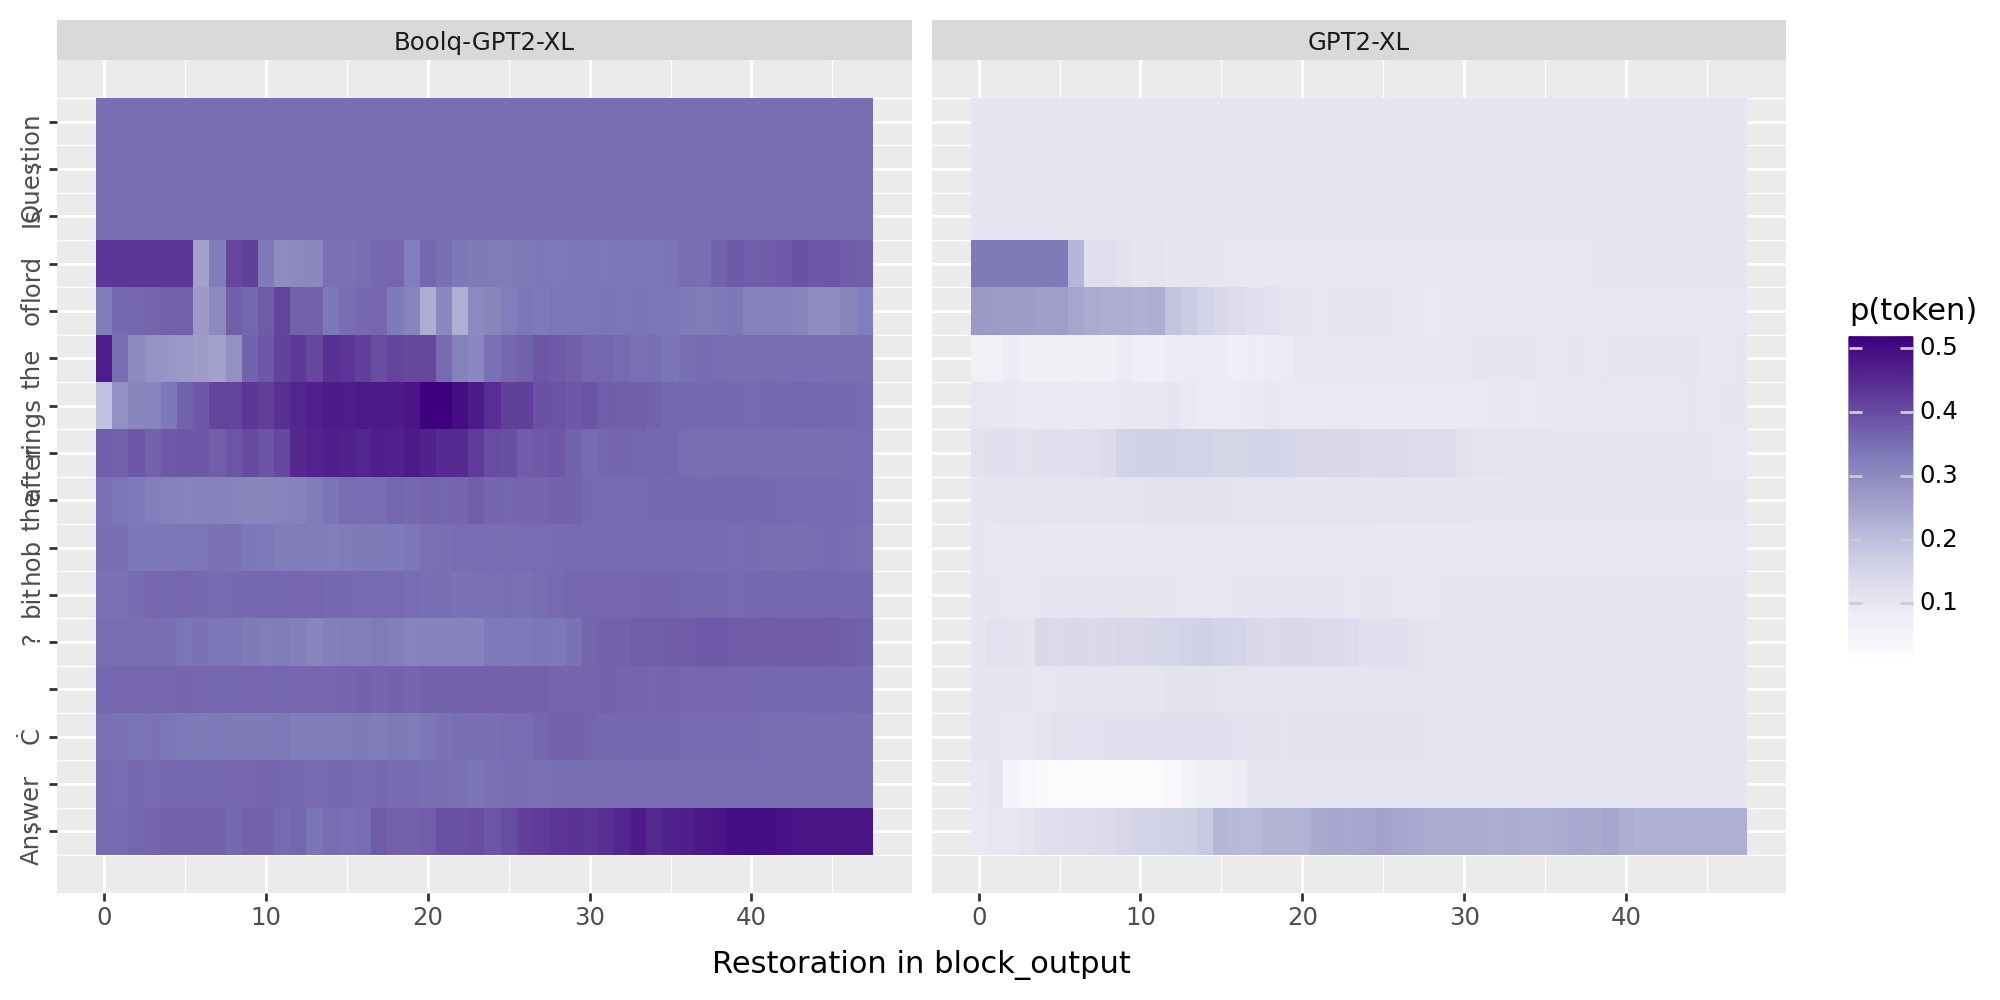

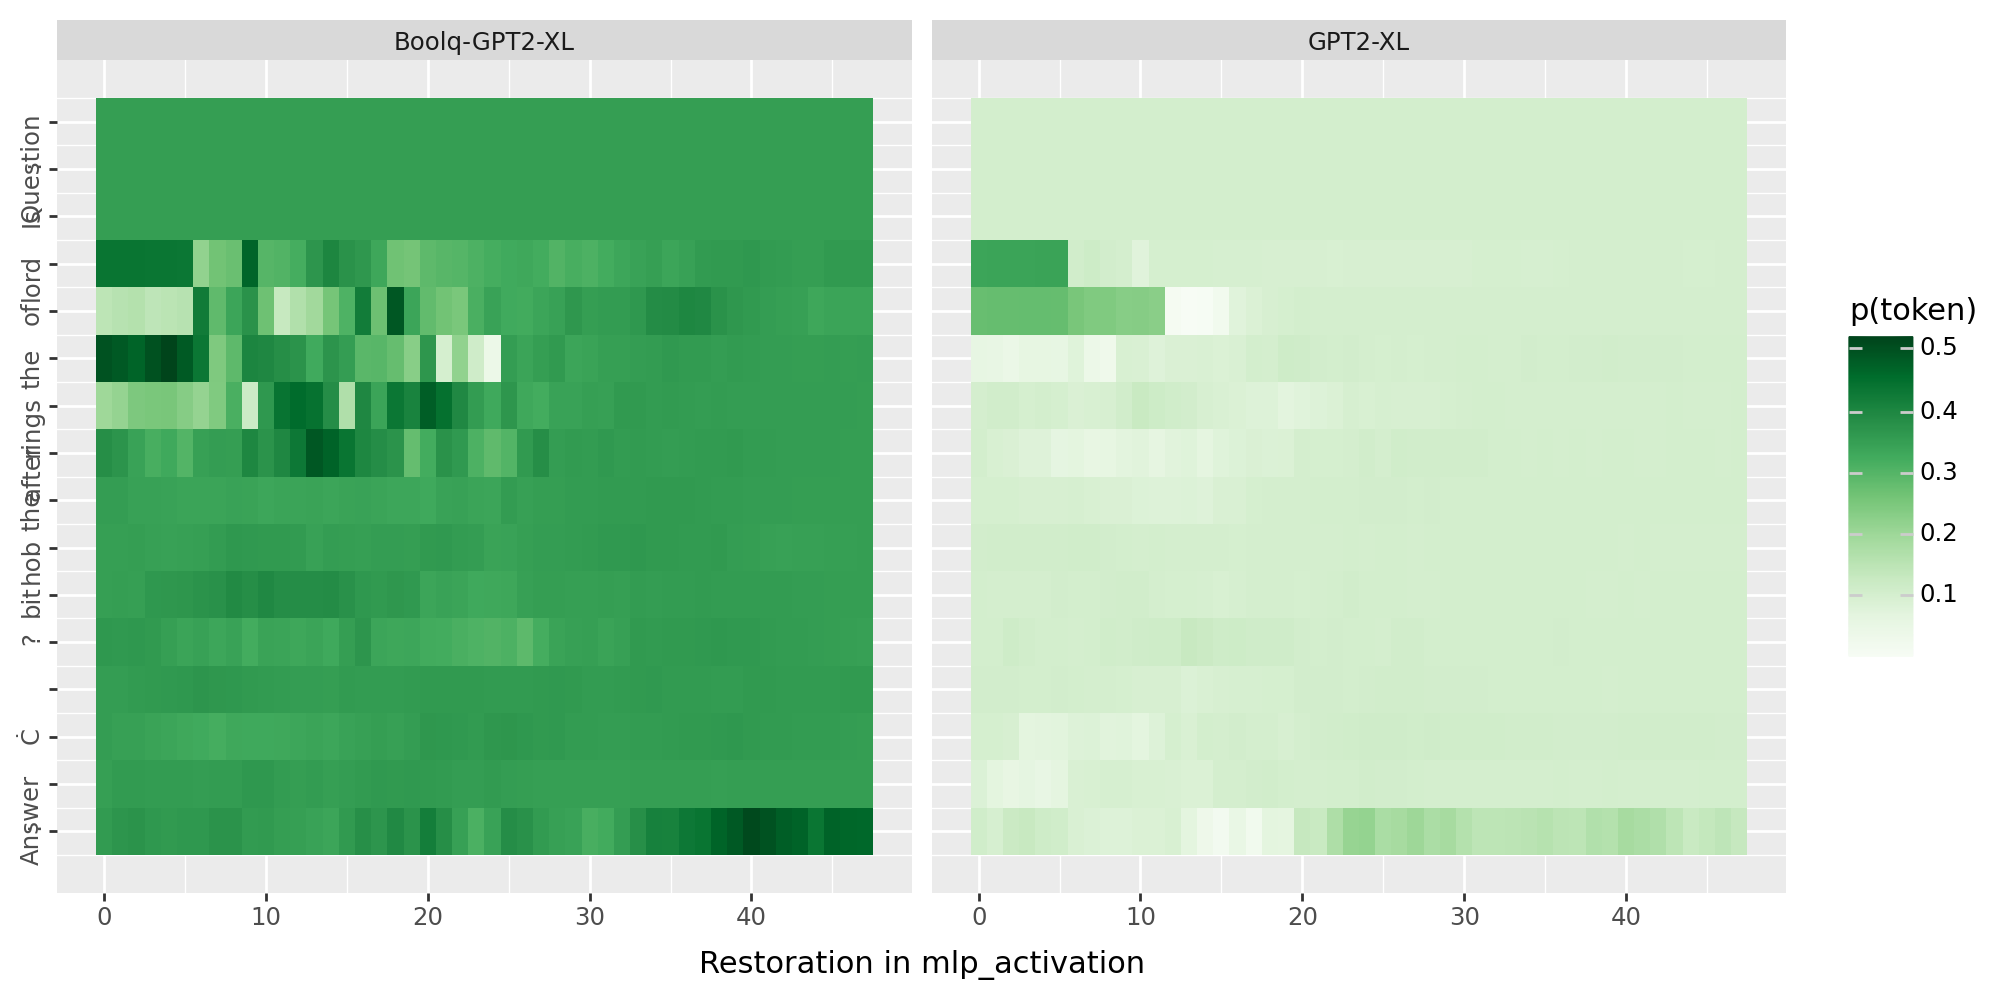

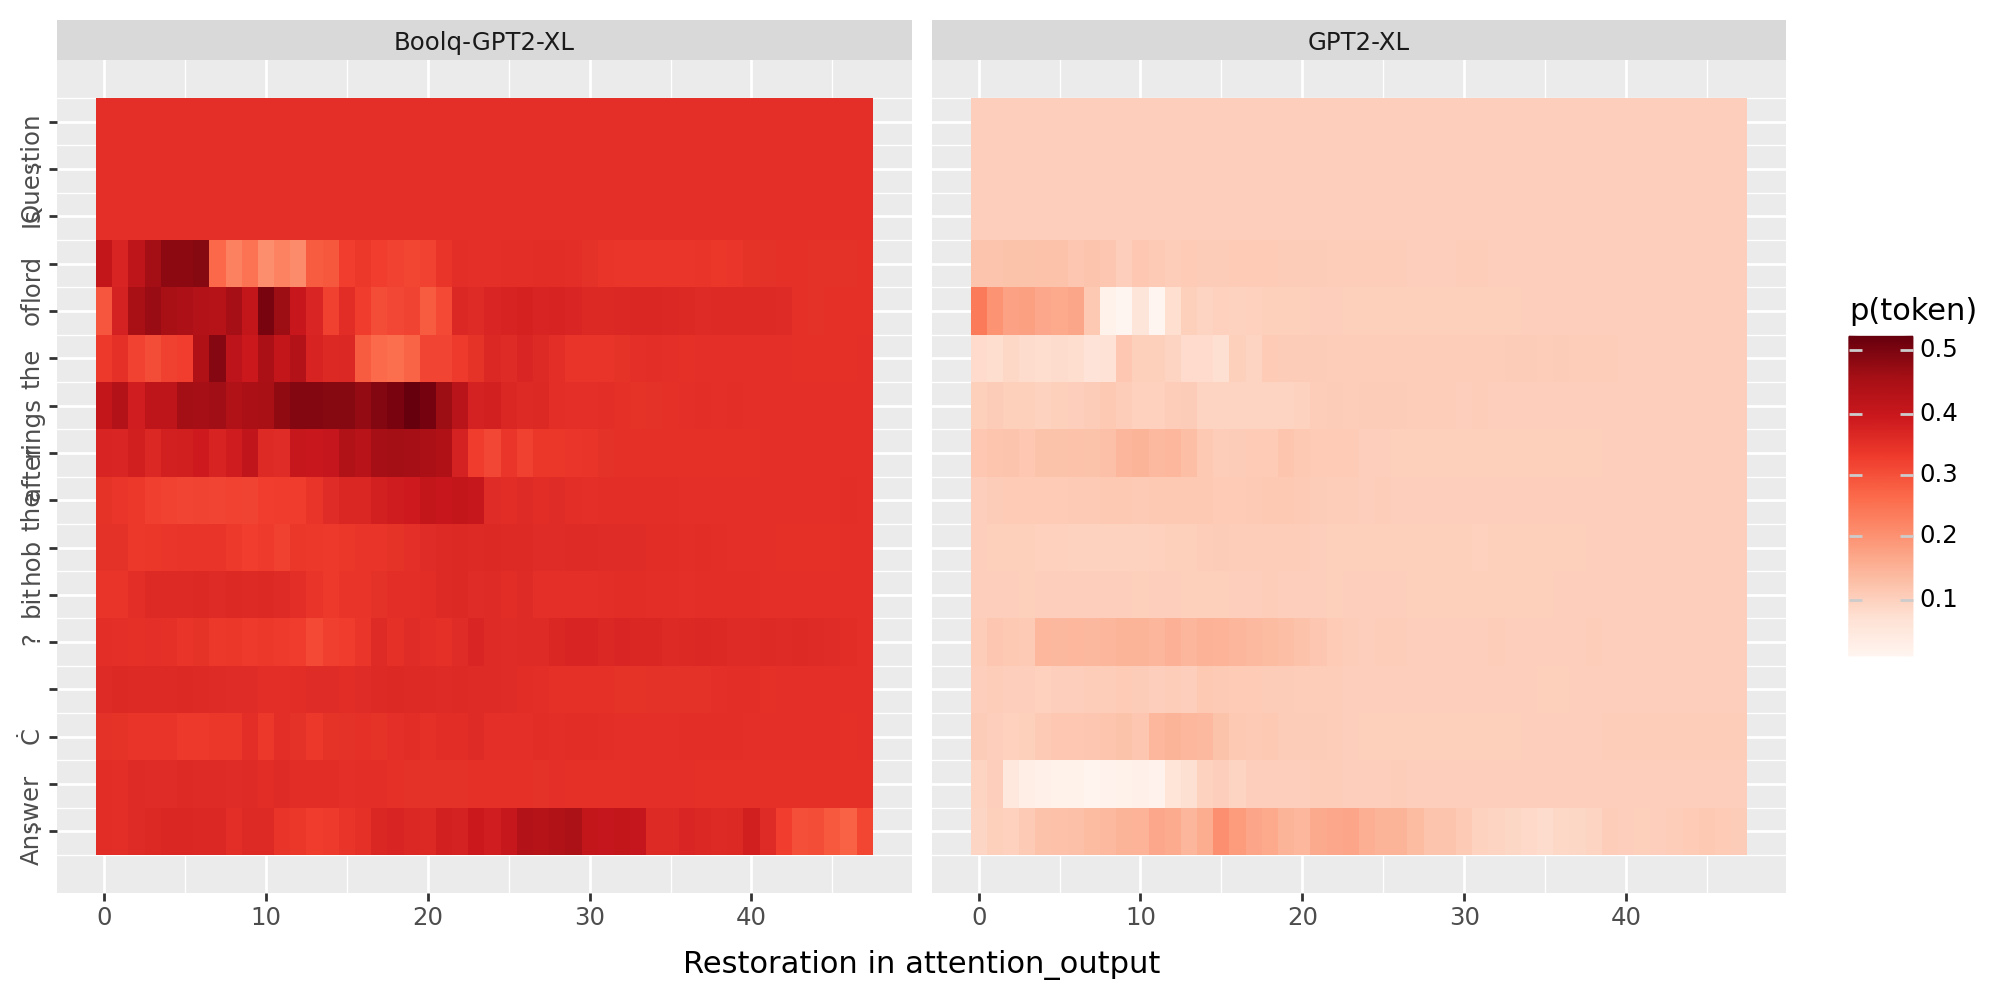

In [45]:
plot_results_comparison(
    target=target,
    sentence=sentence
)

In [66]:
question = "Question: Is porto rico a part of the united states? Answer:"

print(tokenizer.tokenize(question))
print(tokenizer_boolq.tokenize(question))

['Question', ':', 'ĠIs', 'Ġport', 'o', 'Ġr', 'ico', 'Ġa', 'Ġpart', 'Ġof', 'Ġthe', 'Ġunited', 'Ġstates', '?', 'ĠAnswer', ':']
['Question', ':', 'ĠIs', 'Ġport', 'o', 'Ġr', 'ico', 'Ġa', 'Ġpart', 'Ġof', 'Ġthe', 'Ġunited', 'Ġstates', '?', 'ĠAnswer', ':']


In [67]:
sentence = "Question: Is porto rico a part of the united states? Answer:"
target = " Yes"
subject = [4, 5, 6, 7]
print(sentence, ":")
print("GPT2-xl: ")
analyze_sentence(gpt_2xl, tokenizer, config, sentence, target, subject, f"./{target[1:]}/results_gptxl")
print("GPT2-medium: ")
analyze_sentence(gpt_boolq, tokenizer_boolq, config_boolq, sentence, target, subject, f"./{target[1:]}/results_medium")
print("")

Question: Is porto rico a part of the united states? Answer: :
GPT2-xl: 


Analyzing block_output:   0%|          | 0/48 [00:00<?, ?it/s]

Analyzing attention_output: 100%|██████████| 48/48 [03:30<00:00,  4.39s/it]


GPT2-medium: 


Analyzing attention_output: 100%|██████████| 48/48 [03:30<00:00,  4.38s/it]

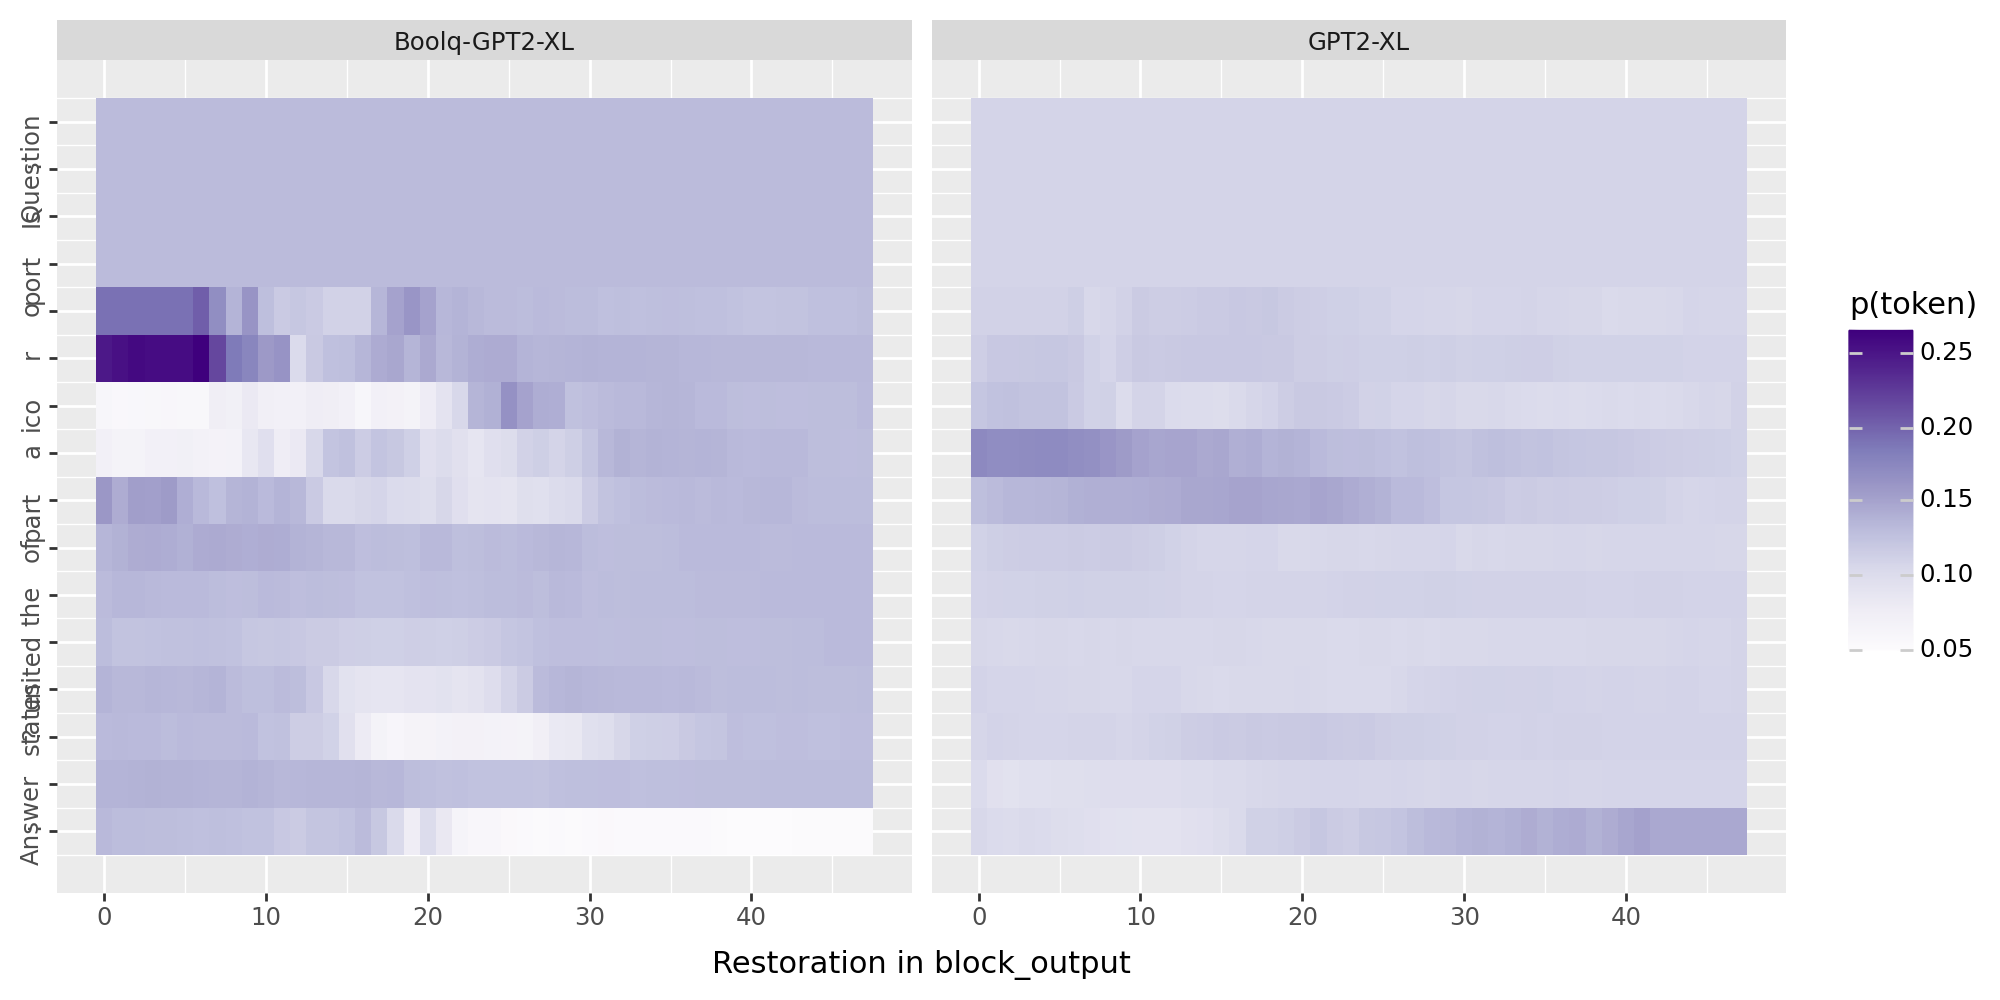

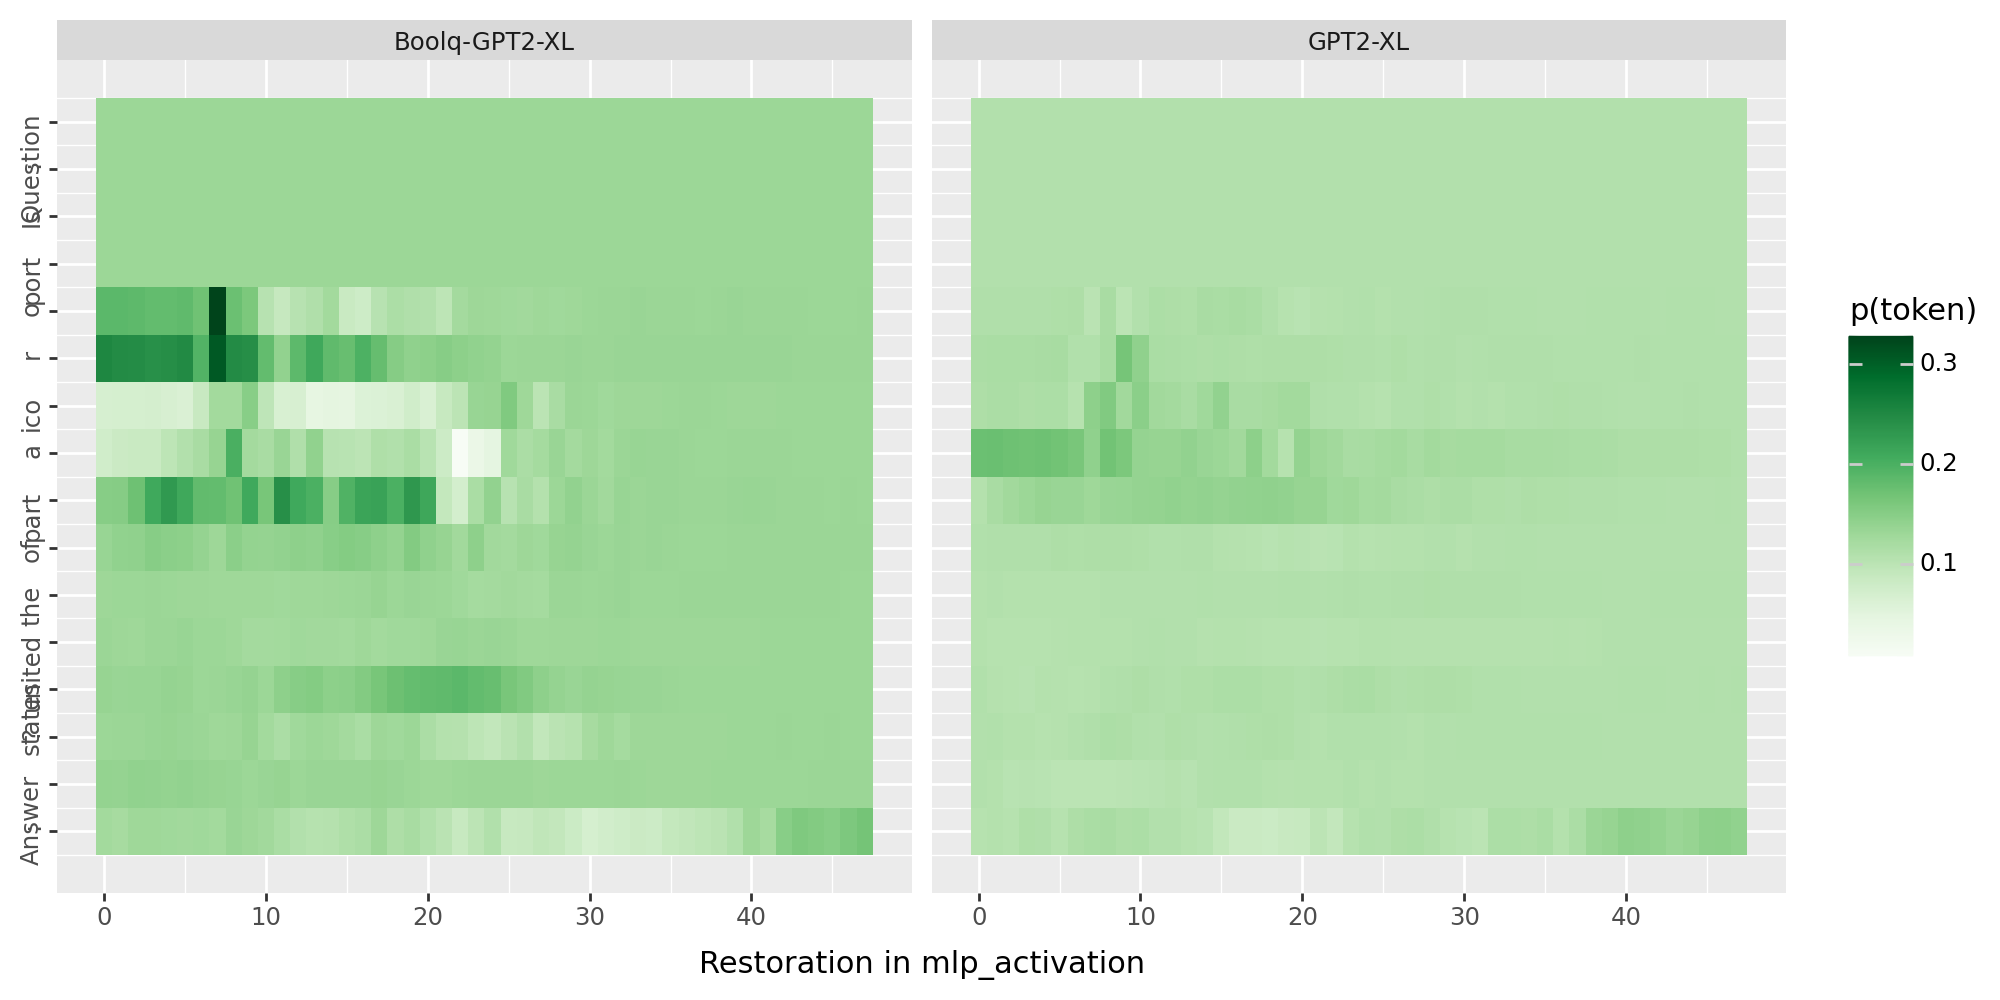

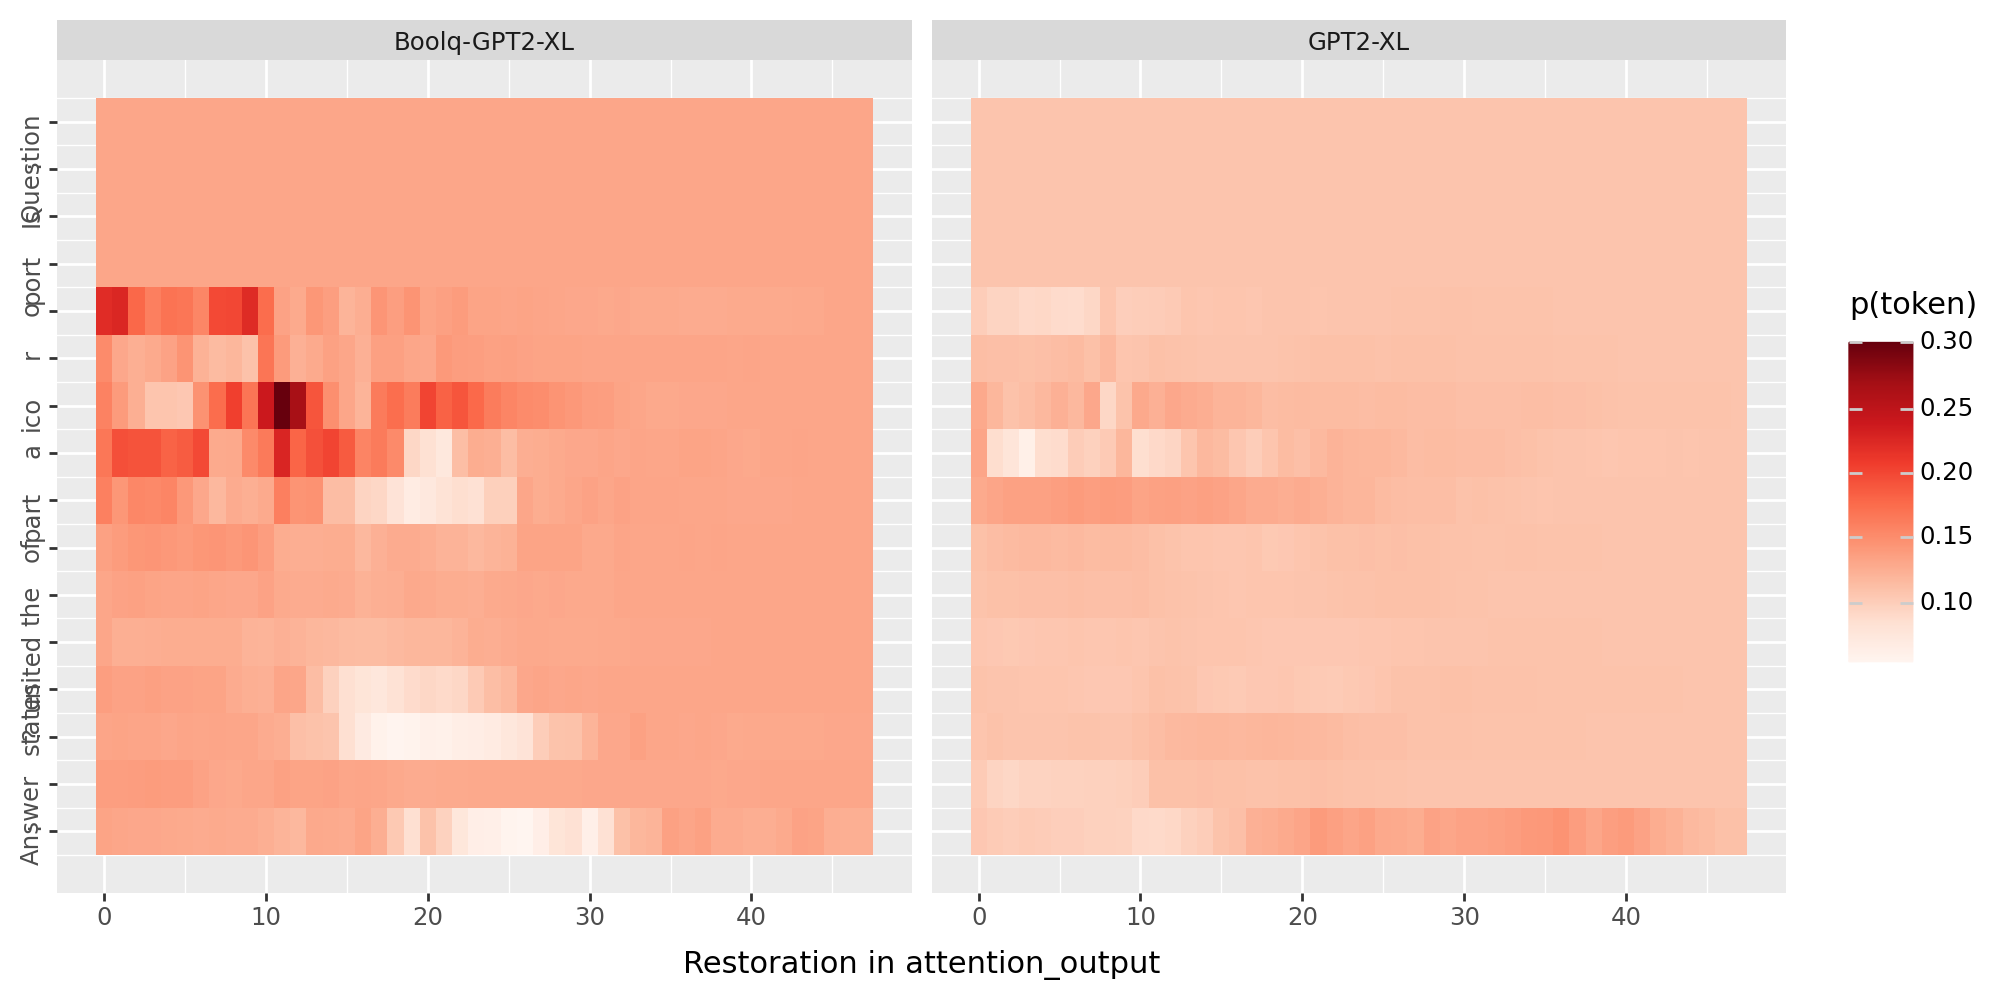

In [68]:
plot_results_comparison(
    target=target,
    sentence=sentence
)